In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror{font-family:Consolas; font-size:15pt;}
div.output{font-size:12pt; font-weight:bold;}
div.input{font-family:Consolas; font-size:12pt;}
div.prompt{min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [8]:
# import
# import seaborn as sns # iris 데이터 
import pandas as pd # 원핫인코딩
import numpy as np
# from sklearn.preprocessing import LabelEncoder # 라벨인코딩(문자->숫자)
# from tensorflow.keras.utils import to_categorical # 원핫인코딩
from sklearn.model_selection import train_test_split # 데이터 분할(층화추출로)
from tensorflow.keras.models import Sequential, load_model, save_model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt # 학습과정 시각화

In [ ]:
# 데이터 생성 및 전처리(라벨인코딩만 하고, 원핫인코딩X)

In [9]:
from sklearn import datasets
iris = datasets.load_iris()
# iris.keys()
iris_X = iris.data
iris_y = iris.target # 라벨인코딩이 되어 있음
iris_X.shape, iris_y.shape
train_X, test_X, train_y, test_y = train_test_split(iris_X, iris_y,
                                                    test_size=0.1,
                                                    stratify=iris_y,
                                                    random_state=4)
train_X.shape, train_y.shape, test_X.shape, test_y.shape

((135, 4), (135,), (15, 4), (15,))

# 1. 기본적인 DNN(원핫인코팅X)

In [11]:
# 모델 설정
# model = Sequential()
# model.add(Input(shape=(4,)))
# model.add(Dense(units=50, activation='relu'))
# model.add(Dense(units=30, activation='relu'))
# model.add(Dense(units=3, activation='softmax'))
model = Sequential([
    Input(4,),
    Dense(units=50, activation='relu'),
    Dense(units=30, activation='relu'),
    Dense(units=3, activation='softmax')
])
model.summary() # 250+1530+93 = 1873개 파라미터

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 50)                250       
                                                                 
 dense_4 (Dense)             (None, 30)                1530      
                                                                 
 dense_5 (Dense)             (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [12]:
# 학습설정
model.compile(loss='sparse_categorical_crossentropy', # 라벨인코딩만 되어 있는 경우에 사용
              optimizer='adam',
              metrics=['accuracy'])
# 학습
earlyStopping = EarlyStopping(patience=50) # monitor = 'val_loss' 기본값
hist = model.fit(train_X, train_y, epochs=1000,
                 validation_split=0.2,
                 callbacks=[earlyStopping])

Epoch 1/1000
4/4 [==============================] - 1s 58ms/step - loss: 1.3645 - accuracy: 0.0833 - val_loss: 1.2323 - val_accuracy: 0.0000e+00
Epoch 2/1000
4/4 [==============================] - 0s 11ms/step - loss: 1.1992 - accuracy: 0.0000e+00 - val_loss: 1.1750 - val_accuracy: 0.2593
Epoch 3/1000
4/4 [==============================] - 0s 12ms/step - loss: 1.1045 - accuracy: 0.5648 - val_loss: 1.1355 - val_accuracy: 0.4815
Epoch 4/1000
4/4 [==============================] - 0s 11ms/step - loss: 1.0461 - accuracy: 0.6667 - val_loss: 1.0983 - val_accuracy: 0.4815
Epoch 5/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.9996 - accuracy: 0.6667 - val_loss: 1.0611 - val_accuracy: 0.4815
Epoch 6/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.9644 - accuracy: 0.6667 - val_loss: 1.0238 - val_accuracy: 0.4074
Epoch 7/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.9300 - accuracy: 0.5833 - val_loss: 0.9841 - val_accuracy: 0.2963
Epoch

Epoch 59/1000
4/4 [==============================] - 0s 14ms/step - loss: 0.2163 - accuracy: 0.9815 - val_loss: 0.1857 - val_accuracy: 0.9259
Epoch 60/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.2180 - accuracy: 0.9815 - val_loss: 0.1824 - val_accuracy: 0.9259
Epoch 61/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.2150 - accuracy: 0.9815 - val_loss: 0.1817 - val_accuracy: 0.9630
Epoch 62/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.2011 - accuracy: 0.9815 - val_loss: 0.1957 - val_accuracy: 0.9630
Epoch 63/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.2047 - accuracy: 0.9537 - val_loss: 0.1912 - val_accuracy: 0.9630
Epoch 64/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.1952 - accuracy: 0.9722 - val_loss: 0.1715 - val_accuracy: 0.9630
Epoch 65/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.1993 - accuracy: 0.9722 - val_loss: 0.1678 - val_accuracy: 0.9259
Epoch 

4/4 [==============================] - 0s 14ms/step - loss: 0.0934 - accuracy: 0.9815 - val_loss: 0.1046 - val_accuracy: 0.9630
Epoch 117/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0926 - accuracy: 0.9815 - val_loss: 0.1002 - val_accuracy: 0.9630
Epoch 118/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0936 - accuracy: 0.9907 - val_loss: 0.0977 - val_accuracy: 0.9259
Epoch 119/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0931 - accuracy: 0.9815 - val_loss: 0.0989 - val_accuracy: 0.9630
Epoch 120/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0910 - accuracy: 0.9907 - val_loss: 0.0978 - val_accuracy: 0.9630
Epoch 121/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0895 - accuracy: 0.9815 - val_loss: 0.1049 - val_accuracy: 0.9630
Epoch 122/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0917 - accuracy: 0.9815 - val_loss: 0.0994 - val_accuracy: 0.9630
Epoch 123/1000

4/4 [==============================] - 0s 11ms/step - loss: 0.0681 - accuracy: 0.9907 - val_loss: 0.0865 - val_accuracy: 0.9630
Epoch 174/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0677 - accuracy: 0.9907 - val_loss: 0.0851 - val_accuracy: 0.9259
Epoch 175/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0702 - accuracy: 0.9815 - val_loss: 0.0855 - val_accuracy: 0.9259
Epoch 176/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0680 - accuracy: 0.9907 - val_loss: 0.0898 - val_accuracy: 0.9630
Epoch 177/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0688 - accuracy: 0.9907 - val_loss: 0.0899 - val_accuracy: 0.9630
Epoch 178/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0681 - accuracy: 0.9907 - val_loss: 0.0884 - val_accuracy: 0.9630
Epoch 179/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0670 - accuracy: 0.9907 - val_loss: 0.0878 - val_accuracy: 0.9630
Epoch 180/1000

4/4 [==============================] - 0s 11ms/step - loss: 0.0599 - accuracy: 0.9907 - val_loss: 0.0834 - val_accuracy: 0.9259
Epoch 231/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0609 - accuracy: 0.9907 - val_loss: 0.0833 - val_accuracy: 0.9259
Epoch 232/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0590 - accuracy: 0.9815 - val_loss: 0.0841 - val_accuracy: 0.9259
Epoch 233/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0578 - accuracy: 0.9907 - val_loss: 0.0874 - val_accuracy: 0.9630
Epoch 234/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0606 - accuracy: 0.9907 - val_loss: 0.0866 - val_accuracy: 0.9630
Epoch 235/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0581 - accuracy: 0.9907 - val_loss: 0.0831 - val_accuracy: 0.9259
Epoch 236/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0594 - accuracy: 0.9907 - val_loss: 0.0833 - val_accuracy: 0.9259
Epoch 237/1000

4/4 [==============================] - 0s 11ms/step - loss: 0.0535 - accuracy: 0.9907 - val_loss: 0.0856 - val_accuracy: 0.9259
Epoch 288/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0592 - accuracy: 0.9815 - val_loss: 0.0842 - val_accuracy: 0.9259
Epoch 289/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0543 - accuracy: 0.9815 - val_loss: 0.0886 - val_accuracy: 0.9630
Epoch 290/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0616 - accuracy: 0.9815 - val_loss: 0.0908 - val_accuracy: 0.9630
Epoch 291/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0526 - accuracy: 0.9907 - val_loss: 0.0855 - val_accuracy: 0.9259
Epoch 292/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0600 - accuracy: 0.9815 - val_loss: 0.0862 - val_accuracy: 0.9259


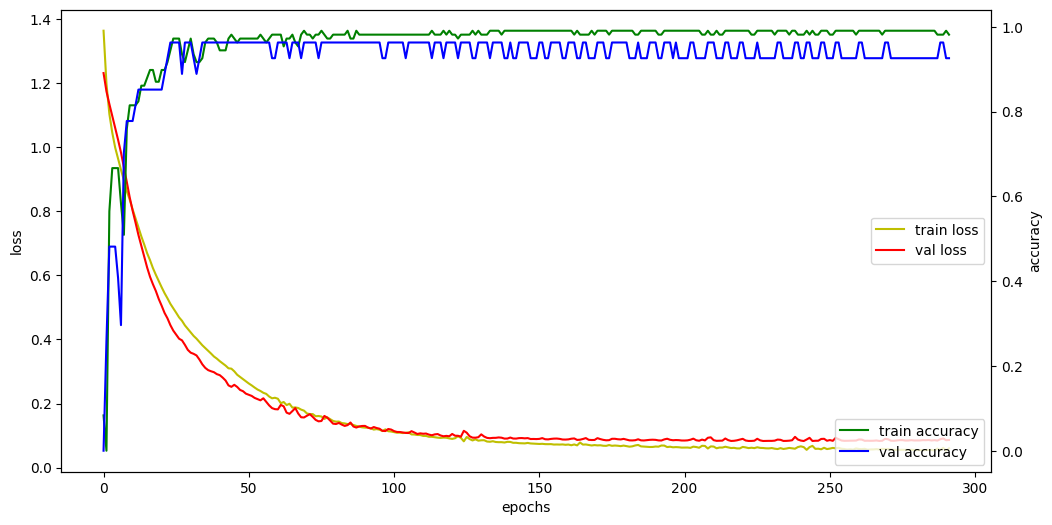

In [13]:
# 모델 학습과정 시각화
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

# 2. sklearn 이용
- 원핫인코딩을 하지 않고 라벨인코딩까지만 해야 작동. numpy 배열

In [14]:
from sklearn.neural_network import MLPClassifier

In [15]:
# 머신러닝 3장 교안 43page
mlp_model = MLPClassifier(hidden_layer_sizes=(50,30),
                      activation='relu',
                      solver='adam',
                      alpha=0.0001, # 과적합 방지 강도
                      batch_size=40,
                      max_iter=1000, # epoch
                      early_stopping=True, # 조기 종료 활성화(val_loss 기준)
                      n_iter_no_change=50, # patience
                      warm_start=False, # True일 경우 이전학습에 이어서 학습
                      validation_fraction=0.1) # 검증셋 비율

In [16]:
mlp_model.fit(train_X, train_y)

MLPClassifier(batch_size=40, early_stopping=True, hidden_layer_sizes=(50, 30),
              max_iter=1000, n_iter_no_change=50)

In [22]:
# 모델 평가 : accuracy(test_X, test_y), recall, precision(test_y, yhat)
from sklearn.metrics import recall_score, precision_score
accuracy = mlp_model.score(test_X, test_y) 
yhat = mlp_model.predict(test_X)
recall = recall_score(test_y, yhat, average='weighted')
precision = precision_score(test_y, yhat, average='weighted')
print('정확도 :', accuracy)
print('재현율 :', recall)
print('정밀도 :', precision)
print('교차표\n', pd.crosstab(test_y, yhat, rownames=['실제'], colnames=['예측']))

정확도 : 0.9333333333333333
재현율 : 0.9333333333333333
정밀도 : 0.9444444444444445
교차표
 예측  0  1  2
실제         
0   5  0  0
1   0  4  1
2   0  0  5


# 3. 클래스 이용

In [23]:
class DNNClassifier:
    @staticmethod
    def build(input_dim=4, activation='relu', optimizer='adam'):
#         model = Sequential()
#         model.add(Input(input_dim,))
#         model.add(Dense(50, activation=activation))
#         model.add(Dense(30, activation=activation))
#         model.add(Dense(3, activation=activation))
        model = Sequential([
            Input(input_dim,),
            Dense(50, activation=activation),
            Dense(30, activation=activation),
            Dense(3, activation='softmax')
        ])
        # 모델 학습 과정 설정
        model.compile(loss='sparse_categorical_crossentropy',
                      optimizer=optimizer,
                      metrics=['accuracy'])
        return model

In [26]:
# 모델
model = DNNClassifier.build(input_dim=4, activation='relu')
model.summary()
# 모델 학습
hist = model.fit(train_X, train_y,
                 epochs=500,
                 validation_split=0.2,
                 verbose=0)

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 50)                250       
                                                                 
 dense_13 (Dense)            (None, 30)                1530      
                                                                 
 dense_14 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [27]:
loss, accuracy = model.evaluate(test_X, test_y)
loss, accuracy

1/1 [==============================] - 0s 24ms/step - loss: 0.0243 - accuracy: 1.0000


(0.024280184879899025, 1.0)

# 4. 함수형 API 이용하기
- 병렬처리 : 속도를 높이려고
- 레지듀얼블록(Residual block) : 모델의 성능을 높이려고(자연어처리, 이미지처리)

In [29]:
# import
import numpy as np
from sklearn.model_selection import train_test_split # 데이터 분할(층화추출로)
from tensorflow.keras import Model # 모델 생성(입력층과 출력층을 이용)
from tensorflow.keras.layers import Dense, Input, add # add는 레지듀얼블록에서 사용
from tensorflow.keras.layers import concatenate # 병렬처리시 필요

In [34]:
from sklearn import datasets
iris = datasets.load_iris()
# iris.keys()
iris_X = iris.data
iris_y = iris.target # 라벨인코딩이 되어 있음
iris_X.shape, iris_y.shape
train_X, test_X, train_y, test_y = train_test_split(iris_X, iris_y,
                                                    test_size=0.1,
                                                    stratify=iris_y,
                                                    random_state=4)
train_X.shape, train_y.shape, test_X.shape, test_y.shape

((135, 4), (135,), (15, 4), (15,))

In [32]:
# 기존의 model 스타일 4 -> 50 -> 30 -> 3
input_ = Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')(input_)
dense2 = Dense(units=30, activation='relu')(dense1)
dense3 = Dense(units=3, activation='softmax')(dense2)
model = Model(inputs=input_, outputs=dense3)
model.summary()
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
model.fit(train_X, train_y, epochs=20,
          validation_split=0.2)

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_7 (InputLayer)        [(None, 4)]               0         
                                                                 
 dense_18 (Dense)            (None, 50)                250       
                                                                 
 dense_19 (Dense)            (None, 30)                1530      
                                                                 
 dense_20 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________
Epoch 1/20
4/4 [==============================] - 0s 48ms/step - loss: 1.1389 - accuracy: 0.3611 - val_loss: 1.1162 - val_accuracy: 0.2222
Epoch 2/20
4/4 [==============================] - 

In [35]:
# 병렬처리
# 4 -> 160(50,80,30로 병렬처리) -> 32 -> 3
input_ = Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')(input_)
dense2 = Dense(units=80, activation='relu')(input_)
dense3 = Dense(units=30, activation='relu')(input_)
x = concatenate([dense1, dense2, dense3])
# x = Dense(160, activation='relu')(input_)의 병렬처리
dense4 = Dense(units=32, activation='relu')(x)
output = Dense(units=3, activation='softmax')(dense4)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_9 (InputLayer)           [(None, 4)]          0           []                               
                                                                                                  
 dense_26 (Dense)               (None, 50)           250         ['input_9[0][0]']                
                                                                                                  
 dense_27 (Dense)               (None, 80)           400         ['input_9[0][0]']                
                                                                                                  
 dense_28 (Dense)               (None, 30)           150         ['input_9[0][0]']                
                                                                                            

In [37]:
%%time
# 레지듀얼블록(Residual Block) : 딥러닝에서 딥한 네트워크가 학습이 잘 되지 않을 때
# 4 -> 50 -> 50 -> (레지듀얼블록) -> 3
input_ = Input(shape=(4,))
dense1 = Dense(50, activation='relu')(input_)
dense2 = Dense(50, activation='relu')(dense1)
dense3 = add([dense1, dense2])
output = Dense(3, activation='softmax')(dense3)
model = Model(inputs=input_, outputs=output)
model.summary()
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
model.fit(train_X, train_y, epochs=500,
          validation_split=0.2, verbose=0)

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_11 (InputLayer)          [(None, 4)]          0           []                               
                                                                                                  
 dense_34 (Dense)               (None, 50)           250         ['input_11[0][0]']               
                                                                                                  
 dense_35 (Dense)               (None, 50)           2550        ['dense_34[0][0]']               
                                                                                                  
 add_1 (Add)                    (None, 50)           0           ['dense_34[0][0]',               
                                                                  'dense_35[0][0]']         

In [38]:
model.evaluate(test_X, test_y)

1/1 [==============================] - 0s 23ms/step - loss: 0.0275 - accuracy: 1.0000


[0.0275439266115427, 1.0]